# Clustering Comparison

Confronto tra run di clustering già **prodotte**. La valutazione di una run alla volta sta in `clustering_evaluation.ipynb`; questo notebook contiene solo ciò che mette a confronto due o più run (ARI/NMI, match matrix, distanze tra centroidi, confronto cross-modalità).

> Le sezioni sono quelle della vecchia versione unica, spostate senza modifiche: da riorganizzare.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from scipy import stats 

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as temp/*/run_prototype.py, needed here for the `from src...` imports below.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

from src.utils.artifacts import load_matrix, read_run_params

sns.set_theme(style="whitegrid")

## Utils

Tutte le funzioni riusabili del notebook, definite una volta sola qui e usate dalle
sezioni numerate sotto - sia in Parte 1 sia in Parte 2 - che quindi contengono solo
l'applicazione (scelta delle run, chiamata, lettura del risultato), non la definizione.
Raggruppate per scope.


### Caricamento run di produzione


In [2]:
def list_production_runs(object_type: str, method: str | None = None) -> pd.DataFrame:
    """Run di produzione già eseguite per 'lesion' o 'sdc', lette dai runs.csv per-metodo
    sotto results/<object_type>/clustering/production/<metodo>/runs.csv - solo indicizzate
    per la selezione manuale qui sotto, nessun dato ricalcolato.

    method: se dato, filtra a un solo sottodirectory (es. "kmeans", "hdbscan") invece di
    leggere tutti i metodi disponibili."""
    if object_type not in ("lesion", "sdc"):
        raise ValueError(f"object_type deve essere 'lesion' o 'sdc', ricevuto {object_type!r}")

    production_root = NOTEBOOK_REPO_ROOT / "results" / object_type / "clustering" / "production"
    if not production_root.is_dir():
        raise FileNotFoundError(f"{production_root} non esiste - nessuna run di produzione per {object_type!r}")

    if method is not None:
        runs_csv_paths = [production_root / method / "runs.csv"]
        if not runs_csv_paths[0].is_file():
            available = sorted(p.parent.name for p in production_root.glob("*/runs.csv"))
            raise FileNotFoundError(
                f"{runs_csv_paths[0]} non esiste - metodo {method!r} sconosciuto o senza run di produzione "
                f"per {object_type!r}. Metodi disponibili: {available}"
            )
    else:
        runs_csv_paths = sorted(production_root.glob("*/runs.csv"))

    if not runs_csv_paths:
        print(f"nessun runs.csv sotto {production_root} - nessuna run di produzione ancora eseguita per {object_type!r}")
        return pd.DataFrame()

    per_method = []
    for runs_csv_path in runs_csv_paths:
        method_df = pd.read_csv(runs_csv_path)
        method_df.insert(0, "method", runs_csv_path.parent.name)  # .../production/<metodo>/runs.csv
        per_method.append(method_df)

    # colonne extra per-metodo (es. linkage per agglomerative, affinity per spectral) non allineate
    # tra metodi diversi: pd.concat le riempie a NaN dove non applicabili, va bene per una tabella di browsing
    return pd.concat(per_method, ignore_index=True, sort=False)


In [3]:
extended_runs: dict[str, dict] = {}  # popolato da load_extended_run - letto anche da
# aligned_labels_intersection, require_shared_embedding e cluster_centroids più sotto


def load_extended_run(name: str, output_dir: str) -> dict:
    """Carica una run di produzione clustering per Parte 1 §8 e Parte 2 §1, nello stesso
    formato del loop di caricamento di Parte 1 §1 (X, metadata, labels, params) più il
    config.md completo (read_run_config) - qui serve anche
    session_name/reduction_method/reduction_n_components/reduction_metric, non solo i
    parametri del modello di clustering, per il controllo esplicito di Parte 1 §8. Registra
    il risultato in extended_runs[name], così le celle successive lo trovano per nome senza
    ricaricarlo."""
    from src.utils.artifacts import read_run_config  # non nel cell di import in cima (non toccato) - serve solo da qui in poi

    input_dir = NOTEBOOK_REPO_ROOT / output_dir
    run_X, run_metadata, _extra_arrays = load_matrix(input_dir)
    extended_runs[name] = {
        "input_dir": input_dir,
        "method": input_dir.parent.parent.name,  # production/<metodo>/<reduction_method>/<run_name>/
        "X": run_X,
        "metadata": run_metadata,
        "labels": run_metadata["cluster_label"].to_numpy(),
        "params": read_run_params(input_dir),
        "config": read_run_config(input_dir),
    }
    return extended_runs[name]


### Visualizzazione


In [4]:
def plot_production_runs(output_dirs: list, plot_file: str = "cluster_plot.png", titles: list | None = None) -> None:
    """Griglia dinamica (quasi quadrata: ceil(sqrt(n)) colonne, ceil(n/colonne) righe) dei
    plot già prodotti in ciascuna output_dir - li carica da disco (plot_file, di default
    cluster_plot.png; passare "silhouette_plot.png" per confrontare quelli), non li ricalcola.

    Esempi di griglia: n=2 -> 1x2, n=3 -> 2x2 (1 vuoto), n=4 -> 2x2, n=5-6 -> 3x2 (con vuoti)."""
    output_dirs = [Path(d) for d in output_dirs]
    if not output_dirs:
        raise ValueError("output_dirs è vuoto - seleziona almeno una run da confrontare")
    if titles is not None and len(titles) != len(output_dirs):
        raise ValueError(f"titles ha {len(titles)} elementi ma output_dirs ne ha {len(output_dirs)}")

    n_runs = len(output_dirs)
    n_cols = int(np.ceil(np.sqrt(n_runs)))
    n_rows = int(np.ceil(n_runs / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
    flat_axes = axes.flatten()

    for i, output_dir in enumerate(output_dirs):
        image_path = output_dir / plot_file
        if not image_path.is_file():
            raise FileNotFoundError(f"{image_path} non esiste - controlla output_dirs/plot_file")
        flat_axes[i].imshow(plt.imread(image_path))
        flat_axes[i].axis("off")
        flat_axes[i].set_title(titles[i] if titles else f"{output_dir.parent.parent.name}/{output_dir.name}", fontsize=9)

    for ax in flat_axes[n_runs:]:  # celle di griglia non usate (es. il 4° slot di una 2x2 con 3 run)
        ax.axis("off")

    fig.tight_layout()


### Allineamento tra run


In [5]:
def aligned_labels(name_a: str, name_b: str) -> tuple[np.ndarray, np.ndarray]:
    subjects_a = runs[name_a]["metadata"]["subject_id"]
    subjects_b = runs[name_b]["metadata"]["subject_id"]
    if not subjects_a.equals(subjects_b):
        raise ValueError(
            f"{name_a!r} and {name_b!r} don't share the exact same subject_id order - align "
            "them explicitly (e.g. a merge on subject_id) before comparing labels positionally"
        )
    return runs[name_a]["labels"], runs[name_b]["labels"]


In [6]:
def aligned_labels_intersection(name_a: str, name_b: str) -> tuple[np.ndarray, np.ndarray, pd.Series]:
    """Come aligned_labels (Parte 1, §4), ma per due run che non condividono lo stesso
    subject_id set/ordine per costruzione (pipeline diverse, es. lesion vs sdc) - qui un
    mismatch non è un bug, è il caso atteso. Inner join su subject_id tra le due run in
    extended_runs (popolato da load_extended_run): ritorna le due label array allineate
    sull'intersezione, nello stesso ordine, più la Series dei subject_id comuni.

    Stampa esplicitamente N soggetti in ciascuna run, N nell'intersezione e N esclusi da
    ciascun lato - un'intersezione parziale non è un errore, ma va sempre resa visibile
    (code_standards.md §0), mai assorbita in silenzio da un merge.

    Raises ValueError se l'intersezione è vuota - le due run non hanno nessun soggetto in
    comune, il confronto non ha senso.
    """
    metadata_a = extended_runs[name_a]["metadata"][["subject_id", "cluster_label"]]
    metadata_b = extended_runs[name_b]["metadata"][["subject_id", "cluster_label"]]

    merged = metadata_a.merge(
        metadata_b, on="subject_id", how="inner", suffixes=(f"_{name_a}", f"_{name_b}")
    )

    n_a, n_b, n_common = len(metadata_a), len(metadata_b), len(merged)
    print(
        f"{name_a}: {n_a} soggetti | {name_b}: {n_b} soggetti | intersezione: {n_common} | "
        f"esclusi solo da {name_a}: {n_a - n_common} | esclusi solo da {name_b}: {n_b - n_common}"
    )
    if merged.empty:
        raise ValueError(
            f"{name_a!r} e {name_b!r} non hanno nessun subject_id in comune - intersezione "
            "vuota, il confronto non ha senso"
        )

    labels_a = merged[f"cluster_label_{name_a}"].to_numpy()
    labels_b = merged[f"cluster_label_{name_b}"].to_numpy()
    return labels_a, labels_b, merged["subject_id"]


### Demografiche/cliniche


In [7]:
# Le demografiche vengono da assets/metadata/participants.csv, la fonte di verità unica del
# progetto (docs/dev/metadata.md): una riga per soggetto, scritta da src/pipeline/populate_metadata.py
# (chi esiste) e src/pipeline/enrich_metadata.py (cosa sappiamo di lui).
#
# Sostituisce l'unione a mano dei vecchi tsv per-dataset di assets/metadata/, cancellati: quel
# codice replicava qui tre cose che ora sono garantite a monte, una volta sola —
#   - l'unione dei dataset in una tabella sola,
#   - il proxy NIHSS di PASPORT (NIHSS_at_presentation, che non ha un NIHSS baseline),
#     ora registrato in enrich_metadata.VARIABLE_SOURCE_OVERRIDES e riportato a ogni run,
#   - il controllo di subject_id duplicati.
PARTICIPANTS_CSV = NOTEBOOK_REPO_ROOT / "assets" / "metadata" / "participants.csv"

DEMOGRAPHIC_COLUMNS = ["age", "sex", "NIHSS", "dataset"]


def load_demographics() -> pd.DataFrame:
    """Età/sesso/NIHSS per soggetto, indicizzati per subject_id.

    I valori numerici sono convertiti esplicitamente: participants.csv si legge con
    dtype=str (per non far mangiare a pandas gli zeri iniziali degli id), quindi age/NIHSS
    arrivano come stringhe e senza questa conversione ogni media a valle sarebbe errata o
    solleverebbe. Una cella non numerica non viene silenziosamente resa NaN: sarebbe
    corruzione dei dati, non un valore mancante.
    """
    if not PARTICIPANTS_CSV.is_file():
        raise FileNotFoundError(
            f"{PARTICIPANTS_CSV} non trovato - va generato con src/pipeline/populate_metadata.py "
            "e src/pipeline/enrich_metadata.py (vedi docs/dev/metadata.md)"
        )
    participants = pd.read_csv(PARTICIPANTS_CSV, dtype=str)

    missing = [c for c in ["subject_id", *DEMOGRAPHIC_COLUMNS] if c not in participants.columns]
    if missing:
        raise ValueError(
            f"{PARTICIPANTS_CSV}: colonne mancanti {missing} - se sono quelle cliniche, "
            "lancia src/pipeline/enrich_metadata.py per popolarle"
        )

    demographics = participants[["subject_id", *DEMOGRAPHIC_COLUMNS]].copy()
    for column in ("age", "NIHSS"):
        demographics[column] = pd.to_numeric(demographics[column], errors="raise")
    return demographics.set_index("subject_id")


In [8]:
def cluster_demographic_profile(labels: np.ndarray, subject_ids: pd.Series, run_label: str) -> pd.DataFrame:
    """Stessa aggregazione di Parte 1 §7 (n, age/NIHSS media ± std, quota maschi %), ma
    parametrizzata su un (labels, subject_ids) qualunque invece di leggere sempre da
    runs[run_name] - qui applicata a entrambe le run di una coppia (Parte 2, §1/§2),
    ristretta ai soggetti dell'intersezione, con la stessa gestione esplicita dei non-match
    verso DEMOGRAPHICS (Parte 1 §7, non ricaricata qui: stessa fonte di verità,
    assets/metadata/participants.csv)."""
    pair_frame = pd.DataFrame(
        {"subject_id": subject_ids.to_numpy(), "cluster_label": labels}
    ).merge(DEMOGRAPHICS, left_on="subject_id", right_index=True, how="left", indicator=True)

    unmatched = pair_frame.loc[pair_frame["_merge"] == "left_only", "subject_id"]
    if not unmatched.empty:
        print(f"{run_label}: {len(unmatched)}/{len(pair_frame)} soggetti senza demografiche in assets/metadata/")
    pair_frame = pair_frame.drop(columns="_merge")

    profile = pair_frame.groupby("cluster_label").agg(
        n=("subject_id", "count"),
        age_mean=("age", "mean"),
        age_std=("age", "std"),
        NIHSS_mean=("NIHSS", "mean"),
        NIHSS_std=("NIHSS", "std"),
        pct_male=("sex", lambda s: (s == "M").mean() * 100),
    )
    profile.insert(0, "run", run_label)
    return profile


In [9]:
DEMOGRAPHICS = load_demographics()

### Confronto entro la stessa pipeline (embedding condiviso)


In [10]:
_SHARED_EMBEDDING_KEYS = ("session_name", "reduction_method", "reduction_n_components", "reduction_metric")


def require_shared_embedding(name_a: str, name_b: str) -> None:
    """Verifica esplicitamente che due run di extended_runs condividano lo stesso embedding
    a monte (stesso session_name/reduction_method/reduction_n_components/reduction_metric) -
    condizione necessaria perché un confronto diretto di centroidi/distanze abbia senso
    (Parte 1, §8). Non basta che il metodo di clustering sia diverso: due run costruite su
    embedding diversi condividono lo stesso spazio solo per coincidenza numerica, mai per
    garanzia.

    Raises ValueError se una qualunque delle 4 chiavi differisce tra le due run, elencando
    quali."""
    config_a = extended_runs[name_a]["config"]
    config_b = extended_runs[name_b]["config"]
    mismatched = {
        key: (config_a.get(key), config_b.get(key))
        for key in _SHARED_EMBEDDING_KEYS
        if config_a.get(key) != config_b.get(key)
    }
    if mismatched:
        raise ValueError(
            f"{name_a!r} e {name_b!r} non condividono lo stesso embedding - chiavi diverse: {mismatched}"
        )


In [11]:
def cluster_centroids(name: str) -> pd.DataFrame:
    """Media delle coordinate embedding per cluster di una run in extended_runs - un
    confronto diretto tra due run ha senso solo dopo require_shared_embedding."""
    run = extended_runs[name]
    dim_columns = [f"dim{i}" for i in range(run["X"].shape[1])]
    return (
        pd.DataFrame(run["X"], columns=dim_columns)
        .assign(cluster_label=run["labels"])
        .groupby("cluster_label")
        .mean()
    )


### Confronto cross-modalità


In [12]:
def cluster_purity_table(row_pct: pd.DataFrame) -> pd.DataFrame:
    """Per ogni riga (cluster sorgente) di una row-normalized contingency table (Parte 2,
    §1), la colonna (cluster di destinazione) dominante e la sua quota (%) - "purezza" di
    quel cluster sorgente. Una riga per cluster sorgente, ordinata dal meno puro (si
    disperde su più cluster di destinazione) al più puro (converge quasi tutto in uno
    solo)."""
    dominant_target_cluster = row_pct.idxmax(axis=1)
    purity_pct = row_pct.max(axis=1)
    return pd.DataFrame(
        {"dominant_target_cluster": dominant_target_cluster, "purity_pct": purity_pct}
    ).sort_values("purity_pct")


## Parte 1 — Confronto entro la stessa pipeline


Le sezioni di questa parte confrontano run che condividono la stessa pipeline (stesso
`object_type`: `lesion` o `sdc`) - varia il metodo di clustering e/o `k`, mai la pipeline a
monte. 
- §1-§7 lavorano su una selezione di run `lesion` (`SELECTED_RUNS`, §1); 
  
- §8 lavora invece su una coppia `sdc` (per mostrare lo stesso tipo di confronto su un'altra modalità) -
la pipeline scelta è un dettaglio della singola sezione, non un vincolo della Parte.

Per il confronto tra pipeline diverse (lesion vs sdc sugli stessi soggetti), vedi Parte 2.


### 1. Loading

Qui si scelgono a mano le run di clustering da confrontare e si caricano da disco. Nessun
dataset sintetico: sono run di produzione **reali**, già eseguite da `clustering.py` e
salvate sotto `results/<lesion|sdc>/clustering/production/<metodo>/<embedding>/<run_name>/`.

Tre passaggi, in ordine:

1. **Vedere quali run esistono** - `list_production_runs(object_type, method=None)` legge
   i `runs.csv` (uno per metodo, scritti dalla pipeline ad ogni run) e li mostra in una
   tabella unica.
   - `object_type`: `"lesion"` o `"sdc"` - obbligatorio, sono due alberi di risultati separati.
  
   - `method`: es. `"kmeans"`, `"hdbscan"` - opzionale; se omesso mostra tutti i metodi insieme.

2. **Scegliere le run da confrontare** - dalla tabella del passaggio 1, si copiano i path
   della colonna `output` (stampati già pronti subito sotto, per copia-incolla) dentro
   `SELECTED_RUNS`.



Seleziona oggetto di indagine e metodo

In [13]:

found_runs = list_production_runs("lesion", method="kmeans")
# found_runs = list_production_runs("lesion")  # senza filtro: tutti i metodi insieme
display(found_runs)  # esplicito (non l'ultima espressione della cella): così appare PRIMA dei path stampati sotto


,method,session,reduction_method,reduction_n_components,reduction_metric,n_clusters,timestamp,input_path,params,output,notes
0,kmeans,s1.1-vol,umap,2,euclidean,4,01-09-26 00:47,results/lesion/dim_reduction/production/umap/1...,"{""n_clusters"": 4, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,"scelta post-tuning 27/28-08, vedi clustering_t..."
1,kmeans,s1.1-vol,umap,2,euclidean,5,01-09-26 09:40,results/lesion/dim_reduction/production/umap/1...,"{""n_clusters"": 5, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,overwrite=true: run riscritto sullo stesso out...
2,kmeans,s1.1-vol,umap,2,euclidean,6,01-09-26 09:41,results/lesion/dim_reduction/production/umap/1...,"{""n_clusters"": 6, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,overwrite=true: run riscritto sullo stesso out...
3,kmeans,s1.2-vol,umap,2,euclidean,4,03-09-26 12:23,results/lesion/dim_reduction/production/umap/2...,"{""n_clusters"": 4, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,Scope 1 - opzione A (k4)
4,kmeans,s1.2-vol,umap,2,euclidean,5,03-09-26 12:23,results/lesion/dim_reduction/production/umap/2...,"{""n_clusters"": 5, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,Scope 1 - opzione B (k5): spectral rbf gamma=1.0
5,kmeans,s1.2-vol,umap,2,euclidean,6,03-09-26 12:24,results/lesion/dim_reduction/production/umap/2...,"{""n_clusters"": 6, ""random_state"": 0, ""n_init"":...",results/lesion/clustering/production/kmeans/um...,Scope 1 - opzione C (k6): spectral rbf gamma=0.1


In [14]:
# path della colonna 'output' pronti per il copia-incolla in SELECTED_RUNS qui sotto, una riga per run
print("\n".join(f'    "{output_path}",' for output_path in found_runs["output"]))


    "results/lesion/clustering/production/kmeans/umap/01-09_s1.1-vol_m_euclidean_nc2_k4",
    "results/lesion/clustering/production/kmeans/umap/01-09_s1.1-vol_m_euclidean_nc2_k5",
    "results/lesion/clustering/production/kmeans/umap/01-09_s1.1-vol_m_euclidean_nc2_k6",
    "results/lesion/clustering/production/kmeans/umap/03-09_s1.2-vol_m_euclidean_nc2_k4",
    "results/lesion/clustering/production/kmeans/umap/03-09_s1.2-vol_m_euclidean_nc2_k5",
    "results/lesion/clustering/production/kmeans/umap/03-09_s1.2-vol_m_euclidean_nc2_k6",


Selezione d'esempio qui sotto per confrontare le run che ci servono, copiando i path stampati sopra.


In [15]:
# nome leggibile -> colonna 'output' di list_production_runs("lesion") (path relativo alla repo root)
SELECTED_RUNS = {
    "kmeans_k5": "results/lesion/clustering/production/kmeans/umap/03-09_s1.2-vol_m_euclidean_nc2_k5",
    "agglomerative_k5": "results/lesion/clustering/production/agglomerative/umap/03-09_s1.2-vol_m_euclidean_nc2_k5_link_average",
    "spectral_k5": "results/lesion/clustering/production/spectral/umap/03-09_s1.2-vol_m_euclidean_nc2_k5_aff_rbf",
    "gmm_k5": "results/lesion/clustering/production/gmm/umap/03-09_s1.2-vol_m_euclidean_nc2_n_comp5_cov_full",
}

runs = {}
for name, output_dir in SELECTED_RUNS.items():
    input_dir = NOTEBOOK_REPO_ROOT / output_dir
    run_X, run_metadata, _extra_arrays = load_matrix(input_dir)
    method = input_dir.parent.parent.name  # production/<metodo>/<reduction_method>/<run_name>/
    runs[name] = {
        "input_dir": input_dir,
        "method": method,
        "X": run_X,
        "metadata": run_metadata,
        "labels": run_metadata["cluster_label"].to_numpy(),
        "params": read_run_params(input_dir),
    }

for name, run in runs.items():
    print(f"{name} ({run['method']}): {run['X'].shape[0]} soggetti, {len(np.unique(run['labels']))} cluster, params={run['params']}")


kmeans_k5 (kmeans): 5269 soggetti, 5 cluster, params={'n_clusters': 5, 'random_state': 0, 'n_init': 'auto'}
agglomerative_k5 (agglomerative): 5269 soggetti, 5 cluster, params={'n_clusters': 5, 'linkage': 'average'}
spectral_k5 (spectral): 5269 soggetti, 5 cluster, params={'n_clusters': 5, 'affinity': 'rbf', 'gamma': 1.0, 'assign_labels': 'cluster_qr', 'random_state': 0}
gmm_k5 (gmm): 5269 soggetti, 5 cluster, params={'n_components': 5, 'covariance_type': 'full', 'random_state': 0}


### 2. Plotting

Confronto puramente visivo delle run in `SELECTED_RUNS`


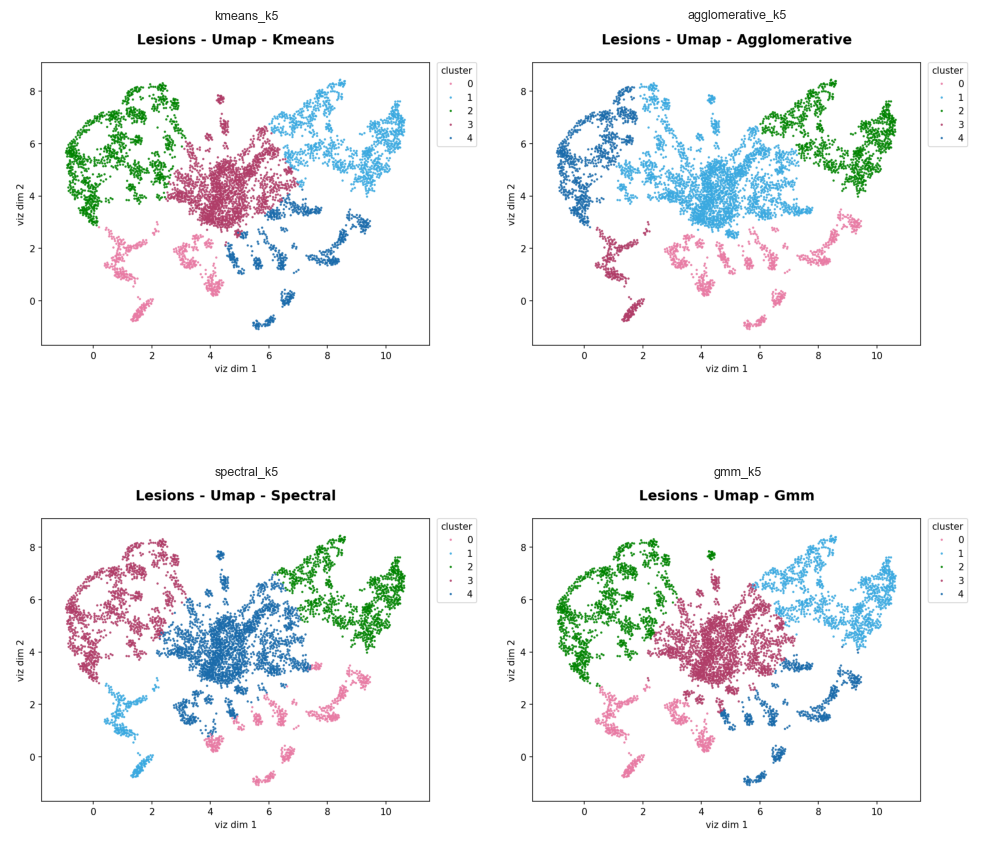

In [16]:
plot_production_runs([run["input_dir"] for run in runs.values()], titles=list(runs.keys()))


### 4. Metriche di confronto diretto: ARI / NMI

Calcoliamo
- **Adjusted Rand Index**: 

  - misura l'accordo tra due partizionamenti (es. clustering ottenuto vs etichette vere/ground truth), correggendo per l'accordo dovuto al caso. Si basa sul conteggio di coppie di punti assegnate in modo concorde/discorde nelle due partizioni.
  
  - A differenza del Rand Index "grezzo", non è gonfiato quando ci sono molti cluster o classi.
  
- **Normalized Mutual Information**: misura quanta informazione condividono due partizionamenti, basata su entropia e informazione mutua, normalizzata per stare in [0, 1].



Prima di confrontare due run verifichiamo esplicitamente che condividano lo stesso ordine di `subject_id`: run che coprissero soggetti diversi andrebbero allineate (es. un merge su `subject_id`) prima di confrontare le label posizionalmente.


> Entrambe richiedono un ground truth (o un secondo clustering) per il confronto — non sono metriche interne come quelle di prima. 
> 
    > - ARI è più conservativo/interpretabile statisticamente (corretto per caso), 
    > 
    > - NMI è più intuitivo informazionalmente ma può sovrastimare la qualità con molte classi/cluster.

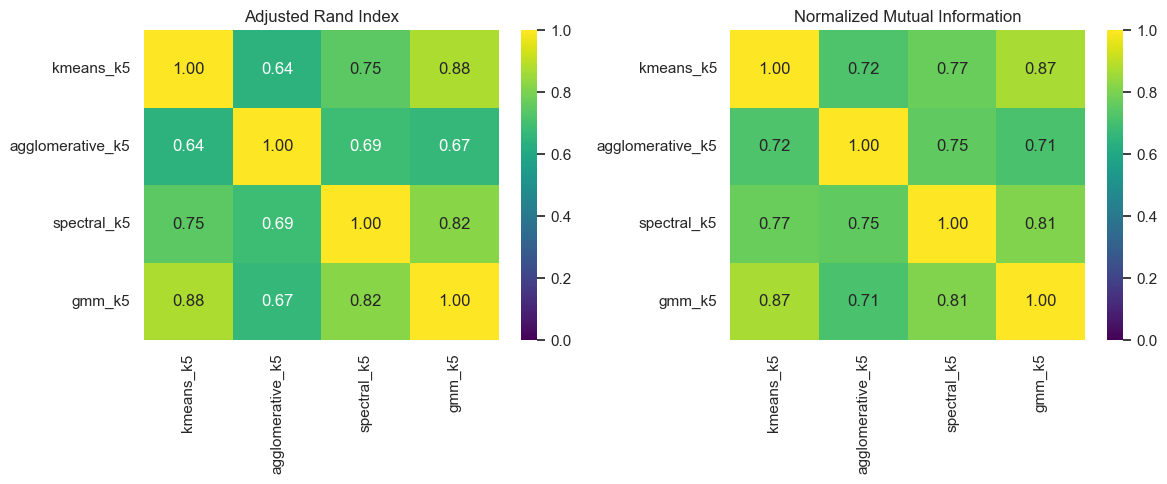

In [17]:
run_names = list(runs.keys())
ari_table = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
nmi_table = pd.DataFrame(index=run_names, columns=run_names, dtype=float)
for name_a in run_names:
    for name_b in run_names:
        labels_a, labels_b = aligned_labels(name_a, name_b)
        ari_table.loc[name_a, name_b] = adjusted_rand_score(labels_a, labels_b)
        nmi_table.loc[name_a, name_b] = normalized_mutual_info_score(labels_a, labels_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(ari_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=axes[0])
axes[0].set_title("Adjusted Rand Index")
sns.heatmap(nmi_table, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="viridis", ax=axes[1])
axes[1].set_title("Normalized Mutual Information")
fig.tight_layout()


**Come leggere la heatmap**

- **Assi**: 
  - righe e colonne sono le stesse run (`kmeans_k5`, `agglomerative_k5`, ...) 

  - ogni cella (riga, colonna) è il valore di ARI/NMI tra quella coppia di run.

  - > quindi vado a misurare l'accordo tra i clustering di due run specifiche, prese a coppia

- **Diagonale**: sempre 1.0 (gialla) - una run confrontata con se stessa, ignorala.

- **Colore**: scala viridis da 0 a 1 - **viola/blu scuro = accordo basso**, **verde =
  accordo medio**, **giallo = accordo alto**. Più la cella è chiara, più le due run si
  assomigliano.

- **Simmetria**: la matrice è simmetrica (cella [a,b] = cella [b,a]) - l'ordine delle
  due run confrontate non conta.

- **Il numero dentro la cella** si legge con questa scala:

- **Confronta i due pannelli fianco a fianco**: stessa coppia di run, due numeri diversi -
  NMI di solito più alto di ARI a parità di somiglianza reale (è meno severo), quindi non
  aspettarti che i colori delle due heatmap coincidano cella per cella.



| Valore | Lettura |
|---|---|
| < 0.2 (ARI) / < 0.3 (NMI) | accordo debole/trascurabile |
| 0.2–0.4 (ARI) / 0.3–0.5 (NMI) | accordo moderato |
| 0.4–0.6 (ARI) / 0.5–0.7 (NMI) | accordo discreto |
| 0.6–0.8 (ARI) / 0.7–0.85 (NMI) | accordo forte |
| > 0.8 (ARI) / > 0.85 (NMI) | quasi identiche |

### 5. Match matrix tra una coppia di run

La contingency matrix è una tabella M[i,j] che conta quanti soggetti sono finiti sia nel cluster i del metodo A (es. K-means) sia nel cluster j del metodo B (es. Agglomerative).

- Righe = cluster del metodo A
  
- Colonne = cluster del metodo B
  
- Cella (i,j) = numero di soggetti in comune tra cluster i (A) e cluster j (B)
  
- È pura sovrapposizione soggetto-per-soggetto: le etichette numeriche dei due metodi sono indipendenti, non c'è alcuna corrispondenza implicita tra "cluster 0 di A" e "cluster 0 di B"
  
- È la base grezza da cui derivano ARI, NMI, ecc.


In [18]:
name_a, name_b = "kmeans_k5", "agglomerative_k5"
labels_a, labels_b = aligned_labels(name_a, name_b)
match_matrix = contingency_matrix(labels_a, labels_b)
match_df = pd.DataFrame(
    match_matrix,
    index=[f"{name_a}={c}" for c in sorted(np.unique(labels_a))],
    columns=[f"{name_b}={c}" for c in sorted(np.unique(labels_b))],
)


match_df



,agglomerative_k5=0,agglomerative_k5=1,agglomerative_k5=2,agglomerative_k5=3,agglomerative_k5=4
kmeans_k5=0,241,0,0,304,1
kmeans_k5=1,0,82,955,0,0
kmeans_k5=2,0,374,0,0,776
kmeans_k5=3,2,1830,1,0,0
kmeans_k5=4,525,178,0,0,0


**Come leggere la match matrix**
- Assi: 
  - righe = cluster di kmeans_k5, 
  
  - colonne = cluster di agglomerative_k5. 
  
  - Non è simmetrica come ARI/NMI — riga e colonna sono due run diverse, l'ordine conta.
  
- **Ogni cella** = numero di soggetti che stanno in entrambi: nel cluster di riga secondo kmeans e nel cluster di colonna secondo agglomerative.

- Le etichette numeriche sono indipendenti: kmeans_k5=0 non è "lo stesso" cluster di agglomerative_k5=0 — sono assegnate arbitrariamente da ciascun algoritmo.

- Non cercare corrispondenza tra numeri, guarda solo dove va la massa.
  
- **Somma di riga i** = dimensione totale del cluster i in kmeans; 
  
- **Somma di colonna j** = dimensione totale del cluster j in agglomerative.

- **Lettura riga per riga**:
  - Massa concentrata in una sola colonna → quel cluster di kmeans corrisponde (quasi) per intero a un unico cluster di agglomerative → accordo

  - Massa sparsa su più colonne → quel cluster viene diviso diversamente dai due metodi → disaccordo


### 8. Centroidi within-modality

A differenza del profilo clinico/demografico cross-cluster (Parte 2, §3), qui il confronto
diretto tra centroidi ha senso, perché le due run condividono esattamente lo stesso
embedding (stesso `session_name`, `reduction_method`, `reduction_n_components`,
`reduction_metric`, quindi stesso `input_path` di dim_reduction a monte) - qui: due metodi
di clustering diversi (kmeans vs agglomerative) sullo stesso `k`, sulla stessa run UMAP 2D
di sdc `s2.2-vol`. Le due run vengono dalla stessa pipeline (sdc), solo il metodo di
clustering cambia - non è un confronto cross-modalità come in Parte 2, anche se qui si usa
sdc invece di lesion come nel resto di questa Parte (§1-§7).

`require_shared_embedding` verifica esplicitamente questa condizione e solleva se le due
run non condividono davvero lo stesso spazio - un confronto di centroidi tra embedding
diversi sarebbe silenziosamente insensato (`code_standards.md` §0).


In [19]:
# nome leggibile -> colonna 'output' di list_production_runs (§1) - stesso session/embedding
# di sdc_kmeans_k4 (Parte 2, §1), solo metodo di clustering diverso
WITHIN_MODALITY_RUNS = {
    "sdc_kmeans_k4": "results/sdc/clustering/production/kmeans/umap/10-09_s2.2-vol_m_euclidean_nc2_k4",
    "sdc_agglomerative_k4": "results/sdc/clustering/production/agglomerative/umap/10-09_s2.2-vol_m_euclidean_nc2_k4_link_average",
}

for name, output_dir in WITHIN_MODALITY_RUNS.items():
    if name not in extended_runs:  # sdc_kmeans_k4 potrebbe già essere in extended_runs da Parte 2 §1, non ricaricarla
        load_extended_run(name, output_dir)

within_a, within_b = "sdc_kmeans_k4", "sdc_agglomerative_k4"
require_shared_embedding(within_a, within_b)

centroids_a = cluster_centroids(within_a)
centroids_b = cluster_centroids(within_b)

from sklearn.metrics import pairwise_distances  # non nel cell di import in cima (non toccato)

centroid_distances = pd.DataFrame(
    pairwise_distances(centroids_a, centroids_b),
    index=[f"{within_a}={c}" for c in centroids_a.index],
    columns=[f"{within_b}={c}" for c in centroids_b.index],
)

print(f"{within_a} centroidi:")
display(centroids_a.round(3))
print(f"\n{within_b} centroidi:")
display(centroids_b.round(3))
print("\nDistanza euclidea centroide-centroide nello spazio embedding condiviso:")
centroid_distances.round(3)


sdc_kmeans_k4 centroidi:


,dim0,dim1
cluster_label,,
0,0.303,8.548
1,8.729,6.655
2,11.895,4.622
3,4.733,8.778



sdc_agglomerative_k4 centroidi:


,dim0,dim1
cluster_label,,
0,7.443,7.980
1,2.621,8.999
2,10.723,4.750
3,-0.336,8.451



Distanza euclidea centroide-centroide nello spazio embedding condiviso:


,sdc_agglomerative_k4=0,sdc_agglomerative_k4=1,sdc_agglomerative_k4=2,sdc_agglomerative_k4=3
sdc_kmeans_k4=0,7.162,2.362,11.090,0.646
sdc_kmeans_k4=1,1.847,6.542,2.757,9.241
sdc_kmeans_k4=2,5.577,10.255,1.180,12.816
sdc_kmeans_k4=3,2.825,2.123,7.218,5.079


## Parte 2 — Confronto cross-modalità

Qui invece si confrontano run di **pipeline diverse** (lesion vs sdc): soggetti diversi per
costruzione 
- `lesion` include soggetti senza un disconnettoma
SDC calcolato 

- e viceversa. 

> Il confronto va quindi fatto sull'**intersezione** dei
`subject_id`, esplicitamente allineata e riportata (`code_standards.md` §0: mai un merge
silenzioso).


### 1. Confronto cross-modalità


Coppia scelta a mano: 
- stesso metodo/`k` (`kmeans_k5`) su lesion (`s1.2-vol`) e su sdc
(`s2.2-vol`)

- così l'unica cosa che varia è la pipeline a monte, non anche il criterio di
clustering.



#### Contingency matrix

In [20]:
# nome leggibile -> colonna 'output' di list_production_runs (Parte 1, §1), stesso stile di
# SELECTED_RUNS - una run per pipeline, stesso metodo/k per isolare l'effetto della sola
# pipeline (lesion vs sdc)
CROSS_MODALITY_RUNS = {
    "lesion_kmeans_k5": "results/lesion/clustering/production/kmeans/umap/03-09_s1.2-vol_m_euclidean_nc2_k5",
    "sdc_kmeans_k5": "results/sdc/clustering/production/kmeans/umap/10-09_s2.2-vol_m_euclidean_nc2_k5",
}

for name, output_dir in CROSS_MODALITY_RUNS.items():
    run = load_extended_run(name, output_dir)
    print(
        f"{name} ({run['method']}, session={run['config']['session_name']}): "
        f"{run['X'].shape[0]} soggetti, {len(np.unique(run['labels']))} cluster, params={run['params']}"
    )


lesion_kmeans_k5 (kmeans, session=s1.2-vol): 5269 soggetti, 5 cluster, params={'n_clusters': 5, 'random_state': 0, 'n_init': 'auto'}
sdc_kmeans_k5 (kmeans, session=s2.2-vol): 1570 soggetti, 5 cluster, params={'n_clusters': 5, 'random_state': 0, 'n_init': 'auto'}


L'obiettivo è vedere se i gruppi trovati usando informazioni diverse si sovrappongono o no.

- `aligned_labels_intersection`: 
  - trova i soggetti presenti in entrambe le run (intersezione) e ne allinea le etichette 

  - necessario perché le due run potrebbero essere state fatte su soggetti parzialmente diversi.
  
- `cross_contingency`: 
  - la contingency matrix classica (righe = cluster di lesion, colonne = cluster di sdc), ma calcolata solo sui soggetti in comune.

Le due normalizzazioni aggiuntive:

- **`cross_row_pct`** 
  - normalizzata per riga, somma=100 su ogni riga
  
  - per ogni cluster di `lesion_kmeans_k5`, in che percentuale si distribuisce nei cluster di `sdc_kmeans_k5`. 
  
  - Risponde a: "il cluster lesionale X finisce prevalentemente in un unico cluster SDC, o si spalma su più?"

- **`cross_col_pct`**
  - normalizzata per colonna, somma=100 su ogni colonna
  
  -  per ogni cluster di `sdc_kmeans_k5`, da quali cluster lesionali proviene. 
  -  Risponde alla domanda simmetrica: "il cluster SDC Y è composto da soggetti di un solo cluster lesionale, o è un mix?"



**Perché servono entrambe**: la contingency matrix grezza dà solo conteggi assoluti, difficili da interpretare se i cluster hanno dimensioni molto diverse. Le percentuali per riga/colonna permettono di leggere la **concentrazione relativa** in entrambe le direzioni — un conteggio alto in una cella può essere "quasi tutto il cluster" in un verso e "una frazione minima" nell'altro, a seconda delle dimensioni totali di riga/colonna.

In [21]:
cross_a, cross_b = "lesion_kmeans_k5", "sdc_kmeans_k5"
labels_a, labels_b, common_subjects = aligned_labels_intersection(cross_a, cross_b)

cross_contingency = pd.DataFrame(
    contingency_matrix(labels_a, labels_b),
    index=[f"{cross_a}={c}" for c in sorted(np.unique(labels_a))],
    columns=[f"{cross_b}={c}" for c in sorted(np.unique(labels_b))],
)

# per riga: dove finisce ogni cluster di cross_a dentro cross_b
cross_row_pct = cross_contingency.div(cross_contingency.sum(axis=1), axis=0) * 100
# per colonna: da quali cluster di cross_a arriva ogni cluster di cross_b
cross_col_pct = cross_contingency.div(cross_contingency.sum(axis=0), axis=1) * 100

print("Contingency table (conteggi, sull'intersezione)")
display(cross_contingency)
print(f"\nRow-normalized (%) - per ogni cluster di {cross_a}, come si distribuisce in {cross_b}")
display(cross_row_pct.round(1))
print(f"\nColumn-normalized (%) - per ogni cluster di {cross_b}, da quali cluster di {cross_a} arriva")
display(cross_col_pct.round(1))



lesion_kmeans_k5: 5269 soggetti | sdc_kmeans_k5: 1570 soggetti | intersezione: 1119 | esclusi solo da lesion_kmeans_k5: 4150 | esclusi solo da sdc_kmeans_k5: 451
Contingency table (conteggi, sull'intersezione)


,sdc_kmeans_k5=0,sdc_kmeans_k5=1,sdc_kmeans_k5=2,sdc_kmeans_k5=3,sdc_kmeans_k5=4
lesion_kmeans_k5=0,36,0,0,33,0
lesion_kmeans_k5=1,1,56,189,3,55
lesion_kmeans_k5=2,265,0,0,46,0
lesion_kmeans_k5=3,32,41,11,126,89
lesion_kmeans_k5=4,2,31,26,23,54



Row-normalized (%) - per ogni cluster di lesion_kmeans_k5, come si distribuisce in sdc_kmeans_k5


,sdc_kmeans_k5=0,sdc_kmeans_k5=1,sdc_kmeans_k5=2,sdc_kmeans_k5=3,sdc_kmeans_k5=4
lesion_kmeans_k5=0,52.2,0.0,0.0,47.8,0.0
lesion_kmeans_k5=1,0.3,18.4,62.2,1.0,18.1
lesion_kmeans_k5=2,85.2,0.0,0.0,14.8,0.0
lesion_kmeans_k5=3,10.7,13.7,3.7,42.1,29.8
lesion_kmeans_k5=4,1.5,22.8,19.1,16.9,39.7



Column-normalized (%) - per ogni cluster di sdc_kmeans_k5, da quali cluster di lesion_kmeans_k5 arriva


,sdc_kmeans_k5=0,sdc_kmeans_k5=1,sdc_kmeans_k5=2,sdc_kmeans_k5=3,sdc_kmeans_k5=4
lesion_kmeans_k5=0,10.7,0.0,0.0,14.3,0.0
lesion_kmeans_k5=1,0.3,43.8,83.6,1.3,27.8
lesion_kmeans_k5=2,78.9,0.0,0.0,19.9,0.0
lesion_kmeans_k5=3,9.5,32.0,4.9,54.5,44.9
lesion_kmeans_k5=4,0.6,24.2,11.5,10.0,27.3


**Come si legge**

`Row-normalized`
- Leggi riga per riga: se una riga ha quasi tutta la massa in una sola colonna → quel cluster lesionale corrisponde quasi per intero a un unico cluster sdc
  
- Se la massa è spalmata su più colonne → quel cluster lesionale viene "diviso" da sdc in più gruppi 

<br>

`Column-normalized`
- Leggi colonna per colonna: se una colonna ha quasi tutta la massa in una sola riga → quel cluster sdc è composto (quasi) esclusivamente da soggetti di un unico cluster lesionale

- Se la massa arriva da più righe → quel cluster sdc è un "mix" di soggetti provenienti da cluster lesionali diversi

#### Tabella ARI/NMI/homogeneity/completeness

Queste quattro metriche riassumono in un numero quanto due partizioni si corrispondono nel complesso:

- **ARI**: accordo tra le due partizioni, corretto per il caso
  
- **NMI**: quanta informazione condividono le due partizioni — è la media armonica di homogeneity e completeness
- **Homogeneity**: quanto ogni cluster di A contiene soggetti di **un solo** cluster di B
- **Completeness**: quanto ogni cluster di B raccoglie soggetti da **un solo** cluster di A

<br>

**L'asimmetria che NMI nasconde**

NMI, essendo una media armonica, per costruzione **appiattisce** la direzione dell'eventuale asimmetria tra homogeneity e completeness — due coppie di run con NMI identica possono avere pattern di disaccordo completamente opposti.

Uno scenario "homogeneity bassa + completeness alta" (o il viceversa) è invisibile guardando solo ARI/NMI. È esattamente il tipo di asimmetria che qui interessa isolare, dato che le due pipeline partono da spazi-feature diversi: non c'è ragione a priori per aspettarsi che la stessa granularità di `k` si comporti simmetricamente nelle due direzioni. Per questo homogeneity e completeness vanno sempre controllate **separatamente**, non solo tramite il valore aggregato di NMI.

In [22]:
from sklearn.metrics import completeness_score, homogeneity_score  # non nel cell di import in cima (non toccato)

cross_ari = adjusted_rand_score(labels_a, labels_b)
cross_nmi = normalized_mutual_info_score(labels_a, labels_b)
cross_homogeneity = homogeneity_score(labels_a, labels_b)
cross_completeness = completeness_score(labels_a, labels_b)

pd.DataFrame(
    {
        "metric": ["ARI", "NMI", "homogeneity", "completeness"],
        "value": [cross_ari, cross_nmi, cross_homogeneity, cross_completeness],
    }
).set_index("metric")


,value
metric,
ARI,0.370656
NMI,0.398025
homogeneity,0.407909
completeness,0.388608


**Come si legge**

- Tutte in [0,1] (ARI può scendere sotto 0): valori vicini a 1 = corrispondenza forte, vicini a 0 = nessuna relazione
  
- Guarda homogeneity e completeness separatamente: se sono sbilanciate (una alta, una bassa), c'è un'asimmetria direzionale che NMI da solo non mostra
- Se tutte alte → le due pipeline (lesion, sdc) catturano la stessa struttura sottostante
- Se sbilanciate o basse → conviene tornare alla contingency matrix/residui per capire quali cluster causano lo squilibrio

#### Test chi-quadro di indipendenza e residui standardizzati


Testa se le due partizioni sono associate in modo statisticamente significativo, poi localizza *dove* si concentra l'associazione.

- **`chi2_contingency`**: test chi-quadro di indipendenza su `cross_contingency`. H0 = "l'appartenenza al cluster lesion è indipendente da quella al cluster sdc"
  
- **`cross_expected`**: la tabella che ci si aspetterebbe **sotto H0**, calcolata dai totali di riga/colonna
  
- **`cross_standardized_residuals`**: per ogni cella, quanto l'osservato si discosta dall'atteso, in unità di deviazione standard (come uno z-score)


chi2=1229.3, dof=16, p=7.54e-252


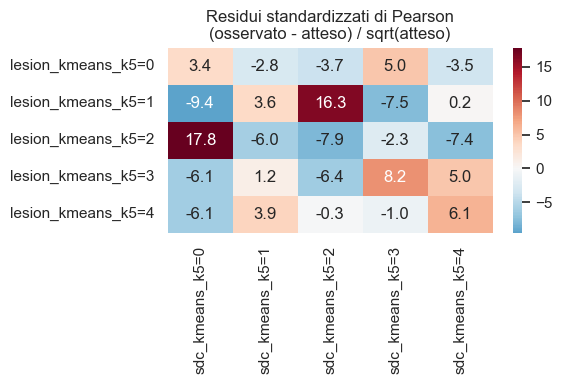

In [23]:
cross_chi2, cross_p_value, cross_dof, cross_expected = stats.chi2_contingency(cross_contingency)

cross_standardized_residuals = pd.DataFrame(
    (cross_contingency.to_numpy() - cross_expected) / np.sqrt(cross_expected),
    index=cross_contingency.index,
    columns=cross_contingency.columns,
)

print(f"chi2={cross_chi2:.1f}, dof={cross_dof}, p={cross_p_value:.2e}")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cross_standardized_residuals, annot=True, fmt=".1f", center=0, cmap="RdBu_r", ax=ax)
ax.set_title("Residui standardizzati di Pearson\n(osservato - atteso) / sqrt(atteso)")
fig.tight_layout()


**Come si legge**

- `p` basso (< 0.05) → si rigetta H0: le due partizioni **non sono indipendenti**, c'è un'associazione reale
  
- **Heatmap dei residui** — dice *dove*:
  - residuo alto e positivo (rosso) → quella coppia di cluster co-occorre **più** del previsto → si "attraggono"
  
  - residuo alto e negativo (blu) → co-occorre **meno** del previsto → si "respingono"
  - residuo vicino a 0 → in linea con l'indipendenza, non contribuisce all'associazione
  
- Il p-value dice **se** c'è associazione globale; i residui dicono **quali** coppie di cluster la determinano

### 2. Purezza per cluster

- **`dominant_target_cluster`**: il cluster di destinazione con la quota più alta per quella riga
  
- **`purity_pct`**: quella quota, in %
- Ordinamento crescente per `purity_pct` → dal cluster **meno puro** (disperso su più cluster di destinazione) al **più puro** (converge quasi tutto in un solo cluster)



Per ogni cluster sorgente (riga della row-normalized table), trova il cluster di destinazione dove finisce la quota maggiore di soggetti (idxmax) e la relativa percentuale (max) — cioè quanto quel cluster sorgente è "puro" (concentrato in un'unica destinazione) invece di disperso.

In [24]:
cluster_purity_table(cross_row_pct)


,dominant_target_cluster,purity_pct
lesion_kmeans_k5=4,sdc_kmeans_k5=4,39.705882
lesion_kmeans_k5=3,sdc_kmeans_k5=3,42.140468
lesion_kmeans_k5=0,sdc_kmeans_k5=0,52.173913
lesion_kmeans_k5=1,sdc_kmeans_k5=2,62.171053
lesion_kmeans_k5=2,sdc_kmeans_k5=0,85.209003


**Come si legge**

- `purity_pct` alta (es. >80%) → quel cluster sorgente ha una corrispondenza netta con un unico cluster di destinazione — accordo forte, coerente con quanto già visto per lesion=2 (84.8%→sdc=0) e lesion=1 (60.6%→sdc=2)
  
- `purity_pct` bassa/moderata → quel cluster si spezza tra più cluster di destinazione — nessuna corrispondenza dominante (coerente con lesion=0 e lesion=3, entrambi divisi su due colonne senza un massimo netto)
- Essendo ordinata dal meno puro al più puro, la tabella fa da riepilogo rapido: le prime righe sono i cluster "problematici" da investigare per capire perché non convergono, le ultime sono le corrispondenze più solide

**Nota**: è solo la metà del quadro — descrive quanto un cluster sorgente converge in una destinazione (~homogeneity a livello di singolo cluster), non se quella destinazione è a sua volta "posseduta" esclusivamente da quel sorgente (quello sarebbe il corrispettivo di completeness, da leggere sulla col-normalized).

### 3. Profilo clinico/demografico cross-cluster

Un confronto diretto dei centroidi tra `cross_a` e `cross_b` non ha senso qui: vivono in
spazi-feature diversi (voxel lesione vs regioni SDC), anche se entrambi ridotti a 2D via
UMAP - le due coordinate non sono la stessa grandezza. 

Il sostituto valido è : non "dove sono
i centroidi" ma "che fenotipo clinico ha ciascun cluster", confrontabile anche tra
spazi-feature diversi perché non dipende dalle coordinate.


In [25]:
pd.concat(
    [
        cluster_demographic_profile(labels_a, common_subjects, cross_a),
        cluster_demographic_profile(labels_b, common_subjects, cross_b),
    ]
)


,run,n,age_mean,age_std,NIHSS_mean,NIHSS_std,pct_male
cluster_label,,,,,,,
0,lesion_kmeans_k5,69,63.362319,13.489616,4.821429,4.160888,56.521739
1,lesion_kmeans_k5,304,65.528239,14.556214,6.996540,6.471357,58.223684
2,lesion_kmeans_k5,311,65.659164,13.548940,6.206667,5.767278,51.125402
3,lesion_kmeans_k5,299,64.647651,15.421137,2.975352,3.928166,57.525084
4,lesion_kmeans_k5,136,65.463235,13.654959,4.952000,5.128755,61.029412
0,sdc_kmeans_k5,336,65.726190,13.630389,6.239875,5.741442,49.702381
1,sdc_kmeans_k5,128,63.671875,14.247591,3.618644,3.974103,64.843750
2,sdc_kmeans_k5,226,65.366071,14.495706,8.740909,6.692268,51.769912
3,sdc_kmeans_k5,231,64.465217,14.828455,2.590476,3.706183,62.770563


## Parte 3 - Other analysis


### Centroidi (selezione libera)

Estrae i centroidi di ogni run selezionata in `SELECTED_CENTROID_RUNS` **una alla volta**
(`cluster_centroids`, `## Utils`) - non richiede che le run condividano l'embedding, quindi
funziona sempre, anche mettendo insieme lesion e sdc.

Il confronto **tra** centroidi (distanza centroide-centroide) ha invece senso solo se due
run condividono lo stesso embedding (stesso `session_name`/`reduction_method`/
`reduction_n_components`/`reduction_metric`) - la cella sotto lo prova per ogni coppia
possibile (`itertools.combinations`) e salta esplicitamente le coppie che non lo
condividono, stampando perché (mai un errore che blocca tutta la cella per una singola
coppia incompatibile, mai un salto silenzioso - `code_standards.md` §0).


In [26]:
# nome leggibile -> colonna 'output' di list_production_runs (Parte 1, §1) - scegli qui
# quali run vuoi vedere. Nessun vincolo di embedding condiviso: ogni run produce i suoi
# centroidi indipendentemente dalle altre. Qui: lesion e sdc insieme, stesso metodo (kmeans)
# - le distanze tra le due (cella sotto) verranno saltate, non condividono l'embedding.
SELECTED_CENTROID_RUNS = {
    "lesion_kmeans_k5": "results/lesion/clustering/production/kmeans/umap/03-09_s1.2-vol_m_euclidean_nc2_k5",
    "sdc_kmeans_k5": "results/sdc/clustering/production/kmeans/umap/10-09_s2.2-vol_m_euclidean_nc2_k4",
}

for name, output_dir in SELECTED_CENTROID_RUNS.items():
    if name not in extended_runs:  # potrebbe essere già stata caricata da un'altra sezione, non ricaricarla
        load_extended_run(name, output_dir)

# centroidi per ogni run, una alla volta - nessun requisito di embedding condiviso qui
centroids_by_run = {}
for name in SELECTED_CENTROID_RUNS:
    centroids_by_run[name] = cluster_centroids(name)
    print(f"{name} centroidi:")
    display(centroids_by_run[name].round(3))


lesion_kmeans_k5 centroidi:


,dim0,dim1
cluster_label,,
0,2.309,1.135
1,8.616,6.166
2,0.908,5.664
3,4.618,4.399
4,6.851,1.944


sdc_kmeans_k5 centroidi:


,dim0,dim1
cluster_label,,
0,0.303,8.548
1,9.132,8.171
2,11.976,4.624
3,4.746,8.765
4,8.493,5.405


Distanza centroide-centroide, solo tra coppie che condividono lo stesso embedding:


In [27]:
from itertools import combinations
from sklearn.metrics import pairwise_distances  # non nel cell di import in cima (non toccato)

for name_a, name_b in combinations(SELECTED_CENTROID_RUNS.keys(), 2):
    try:
        require_shared_embedding(name_a, name_b)
    except ValueError as error:
        print(f"{name_a} vs {name_b}: saltata - {error}\n")
        continue

    centroid_distances = pd.DataFrame(
        pairwise_distances(centroids_by_run[name_a], centroids_by_run[name_b]),
        index=[f"{name_a}={c}" for c in centroids_by_run[name_a].index],
        columns=[f"{name_b}={c}" for c in centroids_by_run[name_b].index],
    )
    print(f"=== {name_a} vs {name_b} ===")
    display(centroid_distances.round(3))
    print()


lesion_kmeans_k5 vs sdc_kmeans_k5: saltata - 'lesion_kmeans_k5' e 'sdc_kmeans_k5' non condividono lo stesso embedding - chiavi diverse: {'session_name': ('s1.2-vol', 's2.2-vol')}

